In [89]:
import os
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
URBAN_LABELS = {
    "0": "air_conditioner",
    "1": "car_horn",
    "2": "children_playing",
    "3": "dog_bark",
    "4": "drilling",
    "5": "engine_idling",
    "6": "gun_shot",
    "7": "jackhammer",
    "8": "siren",
    "9": "street_music"
}

In [91]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000, duration=4)
        y = librosa.util.normalize(y)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc, axis=1)

    except:
        return None

In [92]:
def load_urban(DATA_PATH):
    X, y = [], []

    for fold in os.listdir(DATA_PATH):
        fold_path = os.path.join(DATA_PATH, fold)

        if not os.path.isdir(fold_path):
            continue

        for file in tqdm(os.listdir(fold_path)):
            if file.endswith(".wav"):
                file_path = os.path.join(fold_path, file)

                label = file.split("-")[1]

                features = extract_features(file_path)

                if features is not None:
                    X.append(features)
                    y.append(label)

    return np.array(X), np.array(y)

In [93]:
def load_esc(DATA_PATH):
    X, y = [], []

    for file in tqdm(os.listdir(DATA_PATH)):
        if file.endswith(".wav"):
            file_path = os.path.join(DATA_PATH, file)

            label = file.split("-")[0] 

            features = extract_features(file_path)

            if features is not None:
                X.append(features)
                y.append(label)

    return np.array(X), np.array(y)

In [94]:
# ===== UrbanSound8K =====
X_urban = np.load(r"D:\sound_project\data\X_urban.npy")
y_urban = np.load(r"D:\sound_project\data\y_urban.npy")

# ===== ESC-50 =====
X_esc = np.load(r"D:\sound_project\data\X_esc50.npy")
y_esc = np.load(r"D:\sound_project\data\y_esc50.npy")

print("Urban:", X_urban.shape)
print("ESC:", X_esc.shape)

Urban: (8732, 13)
ESC: (2000, 13)


In [95]:
def run_knn(X, y, name="Dataset"):

    print(f"\n===== {name} =====")

    # chia data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    model = KNeighborsClassifier(
        n_neighbors=7,
        weights='distance'
    )

    # train
    model.fit(X_train, y_train)

    # predict
    y_pred = model.predict(X_test)

    # accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    #SAVE MODEL
    joblib.dump(model, f"{name}_knn.pkl")
    joblib.dump(scaler, f"{name}_scaler.pkl")

    print(f"✅ Saved {name} model!")

    return acc


===== UrbanSound8K =====
Accuracy: 0.8701
                  precision    recall  f1-score   support

 air_conditioner       0.87      0.97      0.92       200
        car_horn       0.97      0.66      0.79        86
children_playing       0.81      0.83      0.82       200
        dog_bark       0.91      0.74      0.82       200
        drilling       0.91      0.86      0.89       200
   engine_idling       0.89      0.96      0.93       200
        gun_shot       0.82      0.75      0.78        75
      jackhammer       0.89      0.93      0.90       200
           siren       0.94      0.96      0.95       186
    street_music       0.75      0.83      0.79       200

        accuracy                           0.87      1747
       macro avg       0.88      0.85      0.86      1747
    weighted avg       0.87      0.87      0.87      1747



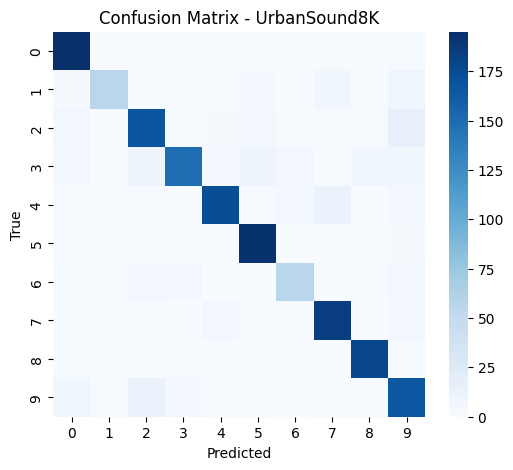

✅ Saved UrbanSound8K model!

===== ESC-50 =====
Accuracy: 0.4
                  precision    recall  f1-score   support

        airplane       0.30      0.38      0.33         8
       breathing       0.25      0.12      0.17         8
  brushing_teeth       0.33      0.25      0.29         8
     can_opening       0.18      0.25      0.21         8
        car_horn       0.25      0.12      0.17         8
             cat       0.57      0.50      0.53         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       1.00      0.38      0.55         8
    church_bells       0.60      0.38      0.46         8
        clapping       0.62      0.62      0.62         8
     clock_alarm       0.86      0.75      0.80         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.10      0.12      0.11         8
             cow       0.83      0.62      0.71         8
  crackling_fire       0.57      0.50      0.53         8
        c

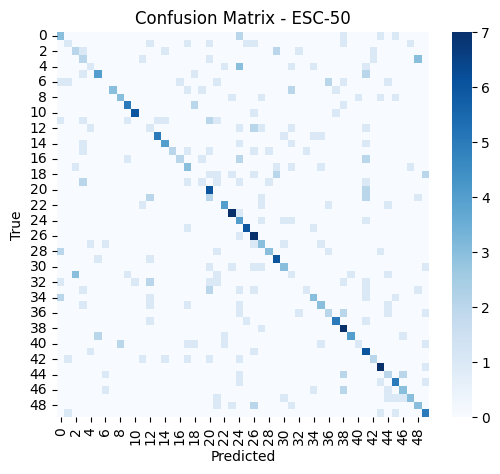

✅ Saved ESC-50 model!


In [96]:
acc_urban = run_knn(X_urban, y_urban, "UrbanSound8K")
acc_esc = run_knn(X_esc, y_esc, "ESC-50")

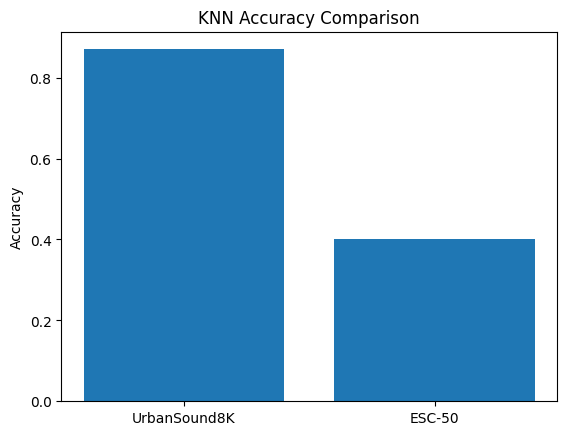

In [97]:
datasets = ["UrbanSound8K", "ESC-50"]
accuracies = [acc_urban, acc_esc]

plt.figure()
plt.bar(datasets, accuracies)
plt.title("KNN Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [98]:
model = joblib.load("UrbanSound8K_knn.pkl")
scaler = joblib.load("UrbanSound8K_scaler.pkl")

model = joblib.load("ESC-50_knn.pkl")
scaler = joblib.load("ESC-50_scaler.pkl")

In [99]:
def demo_urban(file_path):

    features = extract_features(file_path)
    features = features.reshape(1, -1)

    features = scaler.transform(features)

    pred = model.predict(features)[0]
    proba = model.predict_proba(features)
    distances, _ = model.kneighbors(features)

    print("\n===== DEMO UrbanSound8K =====")
    print("File:", file_path)
    print("Predict:", pred)   
    print("Probability:", proba)
    print("Distance:", distances)

In [100]:
file_test = r"D:\sound_project\data\fold8\31325-3-1-1.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\fold8\31325-3-1-1.wav
Predict: door_wood_knock
Probability: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.13506193 0.         0.17041896 0.         0.         0.
  0.12493602 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.14351817 0.
  0.         0.13471231 0.         0.1459794  0.         0.
  0.         0.14537321]]
Distance: [[1.44644623 1.68860722 1.69564853 1.71756552 1.82510249 1.82983923
  1.9730248 ]]


In [101]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-26806-A-1.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-26806-A-1.wav
Predict: rooster
Probability: [[0.         0.         0.         0.         0.         0.10366413
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.09879667
  0.         0.         0.         0.         0.         0.
  0.         0.7975392  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]]
Distance: [[0.98457104 2.77908589 3.32369023 3.46044331 3.60982573 3.63093053
  3.70542612]]


In [102]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-30043-A-26.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-30043-A-26.wav
Predict: sea_waves
Probability: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.11358443 0.         0.         0.
  0.         0.13469187 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.1231245  0.         0.
  0.         0.         0.24610884 0.         0.         0.
  0.         0.         0.24815524 0.13433513 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]]
Distance: [[0.77325944 1.41289886 1.41665091 1.50947254 1.54563865 1.55885341
  1.67545834]]


In [103]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-48298-A-46.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-48298-A-46.wav
Predict: church_bells
Probability: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.42764044 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.11329992 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.09294951 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.36611013 0.         0.         0.         0.
  0.         0.        ]]
Distance: [[0.27159169 1.02509859 1.12247159 1.24953413 1.28343549 1.33883412
  1.36007885]]


In [104]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-39835-A-9.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\1-39835-A-9.wav
Predict: crow
Probability: [[0.         0.         0.         0.         0.         0.
  0.05571181 0.         0.05566813 0.0703813  0.         0.
  0.         0.         0.         0.         0.6354937  0.
  0.         0.05885521 0.         0.         0.         0.
  0.         0.         0.         0.05728972 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.06660012 0.
  0.         0.        ]]
Distance: [[0.21235686 1.91743335 2.02629434 2.29293965 2.3555962  2.42231297
  2.424214  ]]


In [105]:
file_test = r"D:\sound_project\data\fold1\21684-9-0-7.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\fold1\21684-9-0-7.wav
Predict: train
Probability: [[0.         0.         0.         0.         0.         0.13851265
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.1406358  0.
  0.         0.         0.         0.         0.         0.
  0.         0.13838169 0.14380376 0.         0.14489651 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.15107325 0.         0.14269633
  0.         0.        ]]
Distance: [[2.19002765 2.28338566 2.30073685 2.31859225 2.35256312 2.38862367
  2.39088422]]


In [106]:
file_test = r"D:\sound_project\data\fold9\59800-3-0-0.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\fold9\59800-3-0-0.wav
Predict: coughing
Probability: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.30337741 0.         0.         0.         0.         0.
  0.15302569 0.         0.         0.         0.         0.1384088
  0.         0.         0.         0.         0.         0.
  0.14082535 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.13748192 0.
  0.         0.12688083]]
Distance: [[1.61376344 1.82252706 1.98042081 2.0149981  2.02858285 2.13620394
  2.198074  ]]


In [107]:
file_test = r"D:\sound_project\data\fold9\79089-0-0-51.wav"
demo_urban(file_test)


===== DEMO UrbanSound8K =====
File: D:\sound_project\data\fold9\79089-0-0-51.wav
Predict: sea_waves
Probability: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.25874589 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.57595661 0.         0.         0.
  0.         0.         0.         0.         0.1652975  0.
  0.         0.        ]]
Distance: [[1.20396442 1.25477101 1.48759209 1.56516488 1.57439355 1.60087923
  1.60552438]]
